# Sesi 5 - Mini Project Analisis Penjualan Toko

Project ini akan mensimulasikan pengelolaan data yang terdiri dari:
1. Load & eksplorasi data
2. Bersihkan data
3. Analisis & temukan insight
4. Visualisasi
5. Kesimpulan

## 1. Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Buat dataset penjualan toko
data = {
    "tanggal": ["2024-01", "2024-02", "2024-03", "2024-04", "2024-05", "2024-06",
                 "2024-07", "2024-08", "2024-09", "2024-10", "2024-11", "2024-12"],
    "produk": ["Laptop", "HP", "Laptop", "TV", "HP", "Laptop",
                "TV", "HP", "Laptop", "TV", "HP", "Laptop"],
    "kategori": ["Elektronik", "Elektronik", "Elektronik", "Elektronik", "Elektronik", "Elektronik",
                  "Elektronik", "Elektronik", "Elektronik", "Elektronik", "Elektronik", "Elektronik"],
    "penjualan": [150, 200, 180, 90, 220, 170, 95, 210, 160, 100, 230, 190],
    "pendapatan": [225000000, 100000000, 270000000, 135000000, 110000000, 255000000,
                   142500000, 105000000, 240000000, 150000000, 115000000, 285000000]
}

df = pd.DataFrame(data)
print(df)

    tanggal  produk    kategori  penjualan  pendapatan
0   2024-01  Laptop  Elektronik        150   225000000
1   2024-02      HP  Elektronik        200   100000000
2   2024-03  Laptop  Elektronik        180   270000000
3   2024-04      TV  Elektronik         90   135000000
4   2024-05      HP  Elektronik        220   110000000
5   2024-06  Laptop  Elektronik        170   255000000
6   2024-07      TV  Elektronik         95   142500000
7   2024-08      HP  Elektronik        210   105000000
8   2024-09  Laptop  Elektronik        160   240000000
9   2024-10      TV  Elektronik        100   150000000
10  2024-11      HP  Elektronik        230   115000000
11  2024-12  Laptop  Elektronik        190   285000000


## 2. Eksplorasi Data

In [3]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.dtypes)
print("\nStatistik:")
print(df.describe())
print("\nCek missing value:")
print(df.isnull().sum())

Shape: (12, 5)

Info:
tanggal       object
produk        object
kategori      object
penjualan      int64
pendapatan     int64
dtype: object

Statistik:
        penjualan    pendapatan
count   12.000000  1.200000e+01
mean   166.250000  1.777083e+08
std     48.949185  7.121876e+07
min     90.000000  1.000000e+08
25%    137.500000  1.137500e+08
50%    175.000000  1.462500e+08
75%    202.500000  2.437500e+08
max    230.000000  2.850000e+08

Cek missing value:
tanggal       0
produk        0
kategori      0
penjualan     0
pendapatan    0
dtype: int64


## 3. Analisis per Produk

In [5]:
# Total penjualan & pendapatan per produk
per_produk = df.groupby("produk").agg(
    total_penjualan=("penjualan", "sum"),
    total_pendapatan=("pendapatan", "sum"),
    rata_penjualan=("penjualan", "mean")
).reset_index()

print(per_produk)

   produk  total_penjualan  total_pendapatan  rata_penjualan
0      HP              860         430000000           215.0
1  Laptop              850        1275000000           170.0
2      TV              285         427500000            95.0


## 4. Visualisasi — Penjualan & Pendapatan per Produk

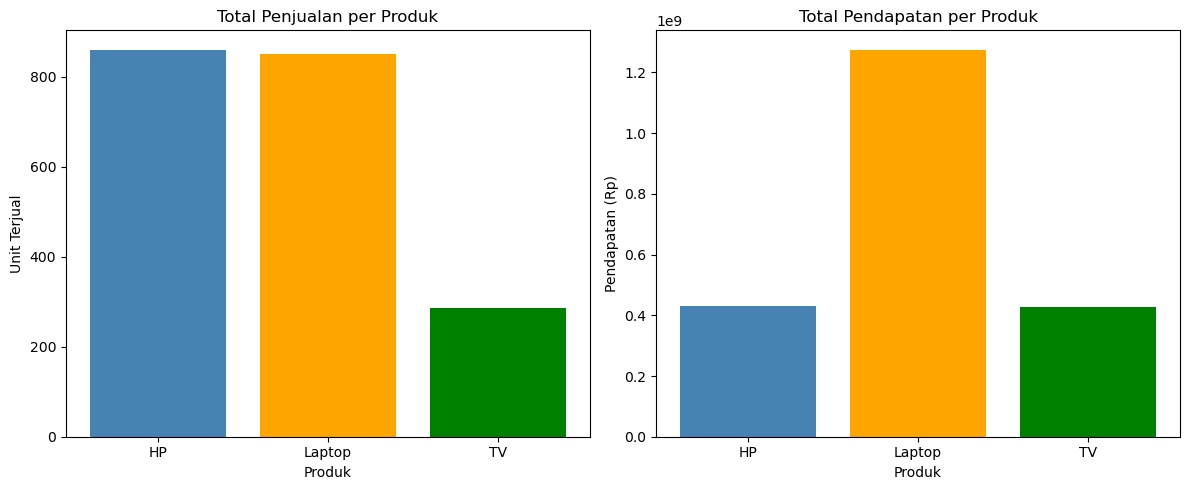

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 — total penjualan
ax1.bar(per_produk["produk"], per_produk["total_penjualan"], color=["steelblue", "orange", "green"])
ax1.set_title("Total Penjualan per Produk")
ax1.set_xlabel("Produk")
ax1.set_ylabel("Unit Terjual")

# Chart 2 — total pendapatan
ax2.bar(per_produk["produk"], per_produk["total_pendapatan"], color=["steelblue", "orange", "green"])
ax2.set_title("Total Pendapatan per Produk")
ax2.set_xlabel("Produk")
ax2.set_ylabel("Pendapatan (Rp)")

plt.tight_layout()
plt.show()

## 5. Kesimpulan & Insight

Berdasarkan analisis data penjualan toko tahun 2024:

In [17]:
print("=" * 45)
print("       LAPORAN ANALISIS PENJUALAN 2024")
print("=" * 45)

for _, row in per_produk.iterrows():
    print(f"\nProduk  : {row['produk']}")
    print(f"Terjual : {row['total_penjualan']} unit")
    print(f"Omzet   : Rp {row['total_pendapatan']:,.0f}")
    print(f"Rata2   : {row['rata_penjualan']:.0f} unit/bulan")

print("\n" + "=" * 45)
print("INSIGHT:")
print("- Laptop menghasilkan omzet tertinggi")
print("- HP paling laris dari segi unit terjual")
print("- TV perlu strategi peningkatan penjualan")
print("=" * 45)

       LAPORAN ANALISIS PENJUALAN 2024

Produk  : HP
Terjual : 860 unit
Omzet   : Rp 430,000,000
Rata2   : 215 unit/bulan

Produk  : Laptop
Terjual : 850 unit
Omzet   : Rp 1,275,000,000
Rata2   : 170 unit/bulan

Produk  : TV
Terjual : 285 unit
Omzet   : Rp 427,500,000
Rata2   : 95 unit/bulan

INSIGHT:
- Laptop menghasilkan omzet tertinggi
- HP paling laris dari segi unit terjual
- TV perlu strategi peningkatan penjualan
